<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/absorption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Equilibrium-stage CO₂ absorption into water with NeqSim

This tutorial uses SRK-CPA phase equilibrium to screen physical absorption of carbon dioxide from
a methane-rich gas into water. It covers one ideal contact stage and a cross-current cascade.

## Learning objectives

After completing the notebook, you should be able to:

- build a reproducible gas–water absorption calculation with explicit units;
- identify gas and aqueous phases after an isothermal, isobaric equilibrium contact;
- calculate CO₂ removal, methane recovery, distribution selectivity, and component closure;
- explain pressure, temperature, and solvent-rate trends;
- simulate a simple cross-current sequence of equilibrium stages; and
- distinguish equilibrium screening from rate-based absorber design.

In [1]:
import importlib.metadata
import subprocess
import sys


subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--quiet",
        "neqsim",
    ],
    check=True,
    capture_output=True,
    text=True,
)

installed_neqsim_version = importlib.metadata.version("neqsim")
print(f"NeqSim {installed_neqsim_version} is ready.")

NeqSim 3.16.0 is ready.


In [2]:
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


java_version_line = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            installed_neqsim_version,
            platform.python_version(),
            java_version_line,
        ],
    }
)
runtime_table

  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21

## Engineering context and model

Physical absorption transfers a soluble gas component into a liquid without explicitly modeling a
chemical reaction. At equilibrium, each component has equal fugacity in all phases. A convenient
distribution coefficient is

$$
K_i = \frac{y_i}{x_i}
$$

where $y_i$ is the gas-phase mole fraction and $x_i$ is the aqueous-phase mole fraction of
component $i$. Water preferentially absorbs CO₂ over methane when

$$
S_{CO_2/CH_4} = \frac{x_{CO_2}/x_{CH_4}}{y_{CO_2}/y_{CH_4}} > 1
$$

The normalized feed contains 0.90 mol methane and 0.10 mol CO₂. The base contact uses 20 mol fresh
water at 298.15 K and 50 bara. SRK-CPA is selected because its association term represents the
strong hydrogen bonding of water; the classic SRK equation alone is not the recommended model for
this water-rich equilibrium screen.

In [3]:
COMPONENTS = ["methane", "CO2", "water"]
MOLECULAR_WEIGHTS_G_PER_MOL = {
    "methane": 16.043,
    "CO2": 44.010,
    "water": 18.015,
}

BASE_GAS_AMOUNTS = {
    "methane": 0.90,
    "CO2": 0.10,
    "water": 0.0,
}
BASE_TEMPERATURE_K = 298.15
BASE_PRESSURE_BAR = 50.0
BASE_WATER_MOL = 20.0

pd.DataFrame(
    {
        "Component": COMPONENTS,
        "Gas-feed amount [mol]": [BASE_GAS_AMOUNTS[name] for name in COMPONENTS],
        "Molecular weight [g/mol]": [
            MOLECULAR_WEIGHTS_G_PER_MOL[name]
            for name in COMPONENTS
        ],
    }
)

  Component  Gas-feed amount [mol]  Molecular weight [g/mol]
0   methane                    0.9                    16.043
1       CO2                    0.1                    44.010
2     water                    0.0                    18.015

## One ideal equilibrium contact

`contact_equilibrium` creates a fresh fluid for every case, performs a TP flash, and extracts phase
amounts directly from NeqSim. Fresh water is added to any water already carried by the entering
gas. This makes the function reusable in a stage cascade without hidden shared state.

In [4]:
def phase_amounts_and_composition(phase):
    phase_moles = float(phase.getNumberOfMolesInPhase())
    composition = {
        name: float(phase.getComponent(name).getx())
        for name in COMPONENTS
    }
    amounts = {
        name: phase_moles * composition[name]
        for name in COMPONENTS
    }
    return amounts, composition


def contact_equilibrium(
    gas_amounts,
    fresh_water_mol,
    temperature_k,
    pressure_bar,
):
    fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(
        float(temperature_k),
        float(pressure_bar),
    )

    total_feed = dict(gas_amounts)
    total_feed["water"] = total_feed.get("water", 0.0) + fresh_water_mol

    for component_name in COMPONENTS:
        fluid.addComponent(component_name, total_feed[component_name])

    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)

    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()

    phases = {}
    for phase_index in range(fluid.getNumberOfPhases()):
        phase = fluid.getPhase(phase_index)
        phase_name = str(phase.getPhaseTypeName())
        amounts, composition = phase_amounts_and_composition(phase)
        phases[phase_name] = {
            "amounts": amounts,
            "composition": composition,
            "moles": float(phase.getNumberOfMolesInPhase()),
            "density_kg_m3": float(phase.getDensity("kg/m3")),
        }

    return {
        "temperature_k": float(temperature_k),
        "pressure_bar": float(pressure_bar),
        "fresh_water_mol": float(fresh_water_mol),
        "feed_amounts": total_feed,
        "phases": phases,
    }

In [5]:
def contact_metrics(result, entering_gas):
    gas_phase = result["phases"]["gas"]
    aqueous_phase = result["phases"]["aqueous"]

    co2_removal = (
        entering_gas["CO2"] - gas_phase["amounts"]["CO2"]
    ) / entering_gas["CO2"]
    methane_recovery = (
        gas_phase["amounts"]["methane"]
        / entering_gas["methane"]
    )

    aqueous_ratio = (
        aqueous_phase["composition"]["CO2"]
        / aqueous_phase["composition"]["methane"]
    )
    gas_ratio = (
        gas_phase["composition"]["CO2"]
        / gas_phase["composition"]["methane"]
    )

    return {
        "co2_removal": co2_removal,
        "methane_recovery": methane_recovery,
        "co2_methane_selectivity": aqueous_ratio / gas_ratio,
    }


base_result = contact_equilibrium(
    BASE_GAS_AMOUNTS,
    BASE_WATER_MOL,
    BASE_TEMPERATURE_K,
    BASE_PRESSURE_BAR,
)
base_metrics = contact_metrics(base_result, BASE_GAS_AMOUNTS)

print(sorted(base_result["phases"]))
print(base_metrics)

['aqueous', 'gas']
{'co2_removal': 0.2906376907991967, 'methane_recovery': 0.9762987723892611, 'co2_methane_selectivity': 16.877018532672682}


## Base-case phase split and performance

The aqueous phase contains most of the water plus absorbed CO₂ and methane. The gas phase retains
most methane. CO₂ removal is

$$
R_{CO_2} = \frac{n_{CO_2,in}-n_{CO_2,gas}}{n_{CO_2,in}}
$$

Methane recovery uses the corresponding gas-out/feed ratio. High CO₂ removal is desirable, while
methane absorption is a product loss that a real process may need to recover.

In [6]:
phase_rows = []

for phase_name in ["gas", "aqueous"]:
    phase = base_result["phases"][phase_name]
    phase_rows.append(
        {
            "Phase": phase_name,
            "Amount [mol]": phase["moles"],
            "Density [kg/m3]": phase["density_kg_m3"],
            "Methane [mol]": phase["amounts"]["methane"],
            "CO2 [mol]": phase["amounts"]["CO2"],
            "Water [mol]": phase["amounts"]["water"],
        }
    )

phase_table = pd.DataFrame(phase_rows)
performance_table = pd.DataFrame(
    {
        "Metric": [
            "CO2 removal",
            "Methane recovery",
            "CO2/CH4 absorption selectivity",
        ],
        "Value": [
            base_metrics["co2_removal"],
            base_metrics["methane_recovery"],
            base_metrics["co2_methane_selectivity"],
        ],
        "Unit": ["mol/mol", "mol/mol", "dimensionless"],
    }
)

display(phase_table.round(6))
display(performance_table.round(6))

     Phase  Amount [mol]  ...  CO2 [mol]  Water [mol]
0      gas      0.950352  ...   0.070936     0.000747
1  aqueous     20.049648  ...   0.029064    19.999253

[2 rows x 6 columns]
                           Metric      Value           Unit
0                     CO2 removal   0.290638        mol/mol
1                Methane recovery   0.976299        mol/mol
2  CO2/CH4 absorption selectivity  16.877019  dimensionless


## Component and mass closure

For each component $i$, an independent stage residual is

$$
r_i = n_{i,gas} + n_{i,aqueous} - n_{i,feed}
$$

The mass residual is reconstructed from molecular weights rather than copied from the simulator.
This catches phase-extraction or unit-basis mistakes even when the flash itself converges.

In [7]:
def component_residuals(result):
    residuals = {}

    for component_name in COMPONENTS:
        output_amount = sum(
            phase["amounts"][component_name]
            for phase in result["phases"].values()
        )
        residuals[component_name] = (
            output_amount - result["feed_amounts"][component_name]
        )

    return residuals


def mass_from_amounts(amounts):
    return sum(
        amounts[name] * MOLECULAR_WEIGHTS_G_PER_MOL[name]
        for name in COMPONENTS
    )


base_component_residuals = component_residuals(base_result)
feed_mass_g = mass_from_amounts(base_result["feed_amounts"])
output_mass_g = sum(
    mass_from_amounts(phase["amounts"])
    for phase in base_result["phases"].values()
)
base_mass_residual_g = output_mass_g - feed_mass_g

closure_table = pd.DataFrame(
    {
        "Component": COMPONENTS,
        "Residual [mol]": [base_component_residuals[name] for name in COMPONENTS],
    }
)
display(closure_table)
print(f"Independent mass residual: {base_mass_residual_g:.3e} g")

  Component  Residual [mol]
0   methane    5.662137e-15
1       CO2    4.579670e-16
2     water   -3.552714e-15
Independent mass residual: 5.684e-14 g


## Pressure and temperature sensitivity

Higher pressure increases gas fugacity and drives more CO₂ into water. Higher temperature reduces
physical-gas solubility over this range, so removal should fall. Every point below is a fresh
equilibrium calculation at the same gas and solvent amounts.

In [8]:
pressure_cases = []

for pressure_bar in [10.0, 30.0, 50.0, 70.0]:
    result = contact_equilibrium(
        BASE_GAS_AMOUNTS,
        BASE_WATER_MOL,
        BASE_TEMPERATURE_K,
        pressure_bar,
    )
    metrics = contact_metrics(result, BASE_GAS_AMOUNTS)
    pressure_cases.append(
        {
            "Pressure [bara]": pressure_bar,
            "CO2 removal [mol/mol]": metrics["co2_removal"],
            "Methane recovery [mol/mol]": metrics["methane_recovery"],
        }
    )

temperature_cases = []

for temperature_k in [283.15, 298.15, 313.15, 328.15]:
    result = contact_equilibrium(
        BASE_GAS_AMOUNTS,
        BASE_WATER_MOL,
        temperature_k,
        BASE_PRESSURE_BAR,
    )
    metrics = contact_metrics(result, BASE_GAS_AMOUNTS)
    temperature_cases.append(
        {
            "Temperature [K]": temperature_k,
            "CO2 removal [mol/mol]": metrics["co2_removal"],
            "Methane recovery [mol/mol]": metrics["methane_recovery"],
        }
    )

pressure_table = pd.DataFrame(pressure_cases)
temperature_table = pd.DataFrame(temperature_cases)
display(pressure_table.round(6))
display(temperature_table.round(6))

   Pressure [bara]  CO2 removal [mol/mol]  Methane recovery [mol/mol]
0             10.0               0.087384                    0.994833
1             30.0               0.210704                    0.985095
2             50.0               0.290638                    0.976299
3             70.0               0.344562                    0.968450
   Temperature [K]  CO2 removal [mol/mol]  Methane recovery [mol/mol]
0           283.15               0.369936                    0.969435
1           298.15               0.290638                    0.976299
2           313.15               0.232863                    0.980602
3           328.15               0.191225                    0.983386


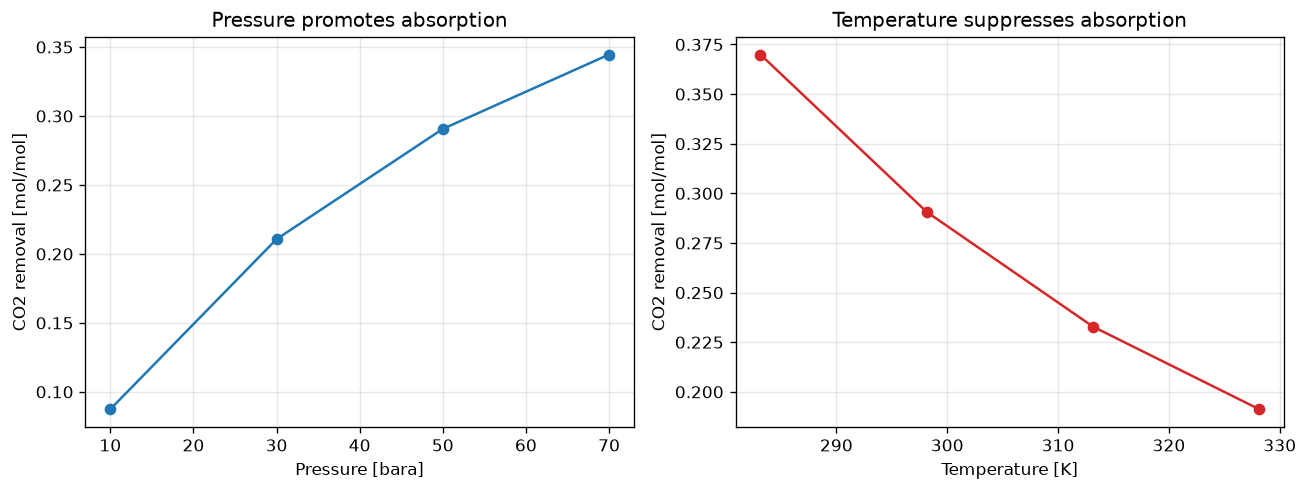

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(
    pressure_table["Pressure [bara]"],
    pressure_table["CO2 removal [mol/mol]"],
    marker="o",
    color="tab:blue",
)
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("CO2 removal [mol/mol]")
axes[0].set_title("Pressure promotes absorption")
axes[0].grid(alpha=0.3)

axes[1].plot(
    temperature_table["Temperature [K]"],
    temperature_table["CO2 removal [mol/mol]"],
    marker="o",
    color="tab:red",
)
axes[1].set_xlabel("Temperature [K]")
axes[1].set_ylabel("CO2 removal [mol/mol]")
axes[1].set_title("Temperature suppresses absorption")
axes[1].grid(alpha=0.3)

figure.tight_layout()
plt.show()

## Solvent-rate sensitivity

Increasing fresh water provides more liquid capacity and raises CO₂ removal. The solvent amounts
are deliberately large on this normalized basis because water is a weak physical solvent compared
with reactive amines. Methane recovery is tracked simultaneously to expose the selectivity tradeoff.

In [10]:
solvent_cases = []

for water_mol in [5.0, 10.0, 20.0, 30.0]:
    result = contact_equilibrium(
        BASE_GAS_AMOUNTS,
        water_mol,
        BASE_TEMPERATURE_K,
        BASE_PRESSURE_BAR,
    )
    metrics = contact_metrics(result, BASE_GAS_AMOUNTS)
    solvent_cases.append(
        {
            "Fresh water [mol/mol gas feed]": water_mol,
            "CO2 removal [mol/mol]": metrics["co2_removal"],
            "Methane recovery [mol/mol]": metrics["methane_recovery"],
        }
    )

solvent_table = pd.DataFrame(solvent_cases)
solvent_table.round(6)

   Fresh water [mol/mol gas feed]  ...  Methane recovery [mol/mol]
0                             5.0  ...                    0.994166
1                            10.0  ...                    0.988262
2                            20.0  ...                    0.976299
3                            30.0  ...                    0.964185

[4 rows x 3 columns]

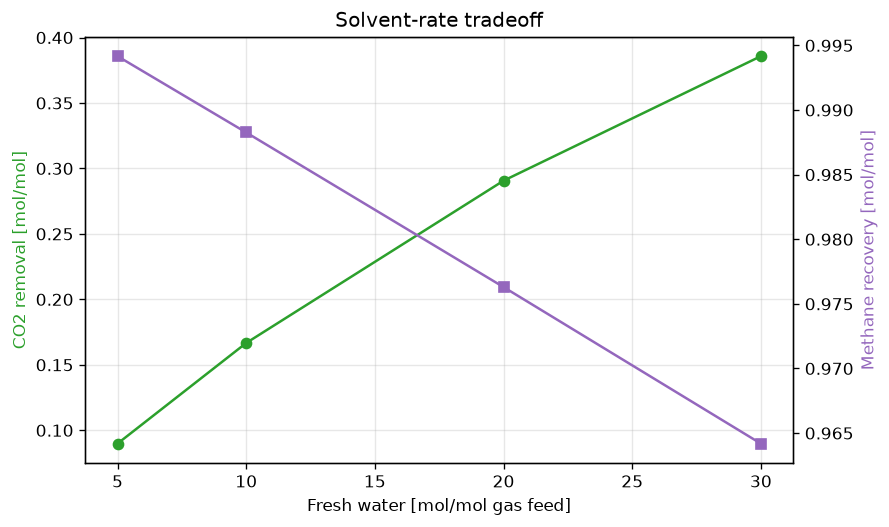

In [11]:
figure, left_axis = plt.subplots(figsize=(7.5, 4.5))
right_axis = left_axis.twinx()

left_axis.plot(
    solvent_table["Fresh water [mol/mol gas feed]"],
    solvent_table["CO2 removal [mol/mol]"],
    marker="o",
    color="tab:green",
)
right_axis.plot(
    solvent_table["Fresh water [mol/mol gas feed]"],
    solvent_table["Methane recovery [mol/mol]"],
    marker="s",
    color="tab:purple",
)

left_axis.set_xlabel("Fresh water [mol/mol gas feed]")
left_axis.set_ylabel("CO2 removal [mol/mol]", color="tab:green")
right_axis.set_ylabel("Methane recovery [mol/mol]", color="tab:purple")
left_axis.set_title("Solvent-rate tradeoff")
left_axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()

## Three-stage cross-current cascade

The gas leaving each ideal stage contacts 10 mol of fresh water in the next stage. Spent aqueous
liquid leaves each stage separately. This is a **cross-current** teaching model, not a counter-current
column: it illustrates repeated equilibrium contact while keeping the bookkeeping transparent.

In [12]:
stage_gas = dict(BASE_GAS_AMOUNTS)
spent_liquids = []
stage_rows = []

for stage_number in range(1, 4):
    stage_result = contact_equilibrium(
        stage_gas,
        10.0,
        BASE_TEMPERATURE_K,
        BASE_PRESSURE_BAR,
    )
    stage_gas = stage_result["phases"]["gas"]["amounts"]
    spent_liquid = stage_result["phases"]["aqueous"]["amounts"]
    spent_liquids.append(spent_liquid)

    stage_rows.append(
        {
            "Stage": stage_number,
            "Cumulative CO2 removal [mol/mol]": (
                1.0 - stage_gas["CO2"] / BASE_GAS_AMOUNTS["CO2"]
            ),
            "Cumulative methane recovery [mol/mol]": (
                stage_gas["methane"] / BASE_GAS_AMOUNTS["methane"]
            ),
            "Gas CO2 amount [mol]": stage_gas["CO2"],
        }
    )

stage_table = pd.DataFrame(stage_rows)
stage_table.round(6)

   Stage  ...  Gas CO2 amount [mol]
0      1  ...              0.083333
1      2  ...              0.069143
2      3  ...              0.057131

[3 rows x 4 columns]

In [13]:
cascade_feed = {
    "methane": BASE_GAS_AMOUNTS["methane"],
    "CO2": BASE_GAS_AMOUNTS["CO2"],
    "water": 30.0,
}
cascade_outputs = {
    name: stage_gas[name] + sum(liquid[name] for liquid in spent_liquids)
    for name in COMPONENTS
}
cascade_residuals = {
    name: cascade_outputs[name] - cascade_feed[name]
    for name in COMPONENTS
}

display(
    pd.DataFrame(
        {
            "Component": COMPONENTS,
            "Cascade residual [mol]": [
                cascade_residuals[name]
                for name in COMPONENTS
            ],
        }
    )
)
print(
    "Final cumulative CO2 removal: "
    f"{stage_table.iloc[-1]['Cumulative CO2 removal [mol/mol]']:.6f}"
)
print(
    "Final cumulative methane recovery: "
    f"{stage_table.iloc[-1]['Cumulative methane recovery [mol/mol]']:.6f}"
)

  Component  Cascade residual [mol]
0   methane            3.996803e-15
1       CO2            2.636780e-16
2     water           -3.552714e-15
Final cumulative CO2 removal: 0.428694
Final cumulative methane recovery: 0.964410


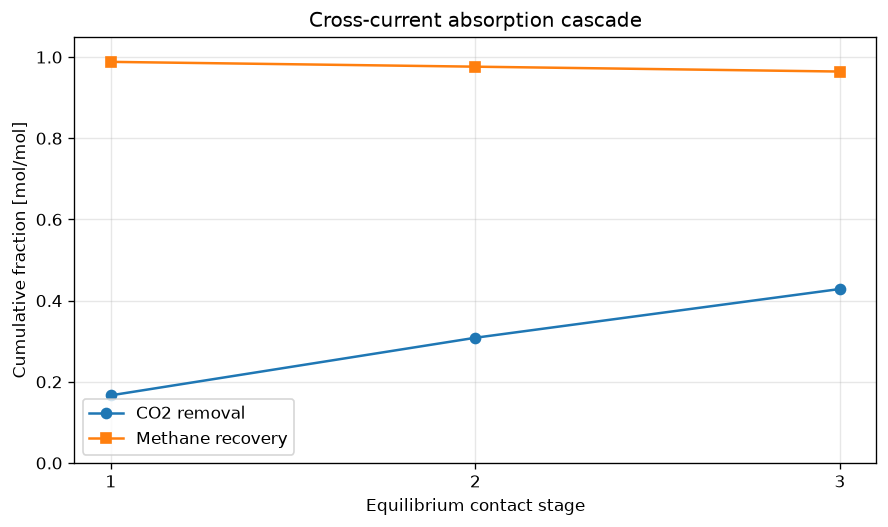

In [14]:
figure, axis = plt.subplots(figsize=(7.5, 4.5))

axis.plot(
    stage_table["Stage"],
    stage_table["Cumulative CO2 removal [mol/mol]"],
    marker="o",
    label="CO2 removal",
)
axis.plot(
    stage_table["Stage"],
    stage_table["Cumulative methane recovery [mol/mol]"],
    marker="s",
    label="Methane recovery",
)

axis.set_xlabel("Equilibrium contact stage")
axis.set_ylabel("Cumulative fraction [mol/mol]")
axis.set_xticks(stage_table["Stage"])
axis.set_ylim(0.0, 1.05)
axis.set_title("Cross-current absorption cascade")
axis.grid(alpha=0.3)
axis.legend()
figure.tight_layout()
plt.show()

## Focused validation checks

The assertions below cover phase identity, finite and non-negative results, component and mass
closure, solvent selectivity, plausible densities and recoveries, expected operating trends, and
complete cascade bookkeeping.

In [15]:
checks = []


def record_check(condition, message):
    assert condition, message
    checks.append(message)


base_phase_amounts = np.array(
    [
        amount
        for phase in base_result["phases"].values()
        for amount in phase["amounts"].values()
    ]
)
pressure_removals = pressure_table["CO2 removal [mol/mol]"].to_numpy()
temperature_removals = temperature_table["CO2 removal [mol/mol]"].to_numpy()
solvent_removals = solvent_table["CO2 removal [mol/mol]"].to_numpy()
stage_removals = stage_table["Cumulative CO2 removal [mol/mol]"].to_numpy()
stage_methane_recoveries = stage_table[
    "Cumulative methane recovery [mol/mol]"
].to_numpy()

record_check(set(base_result["phases"]) == {"gas", "aqueous"}, "Two expected phases")
record_check(np.all(np.isfinite(base_phase_amounts)), "Finite base phase amounts")
record_check(np.all(base_phase_amounts >= 0.0), "Non-negative base phase amounts")
record_check(abs(base_component_residuals["methane"]) < 1.0e-12, "Methane closure")
record_check(abs(base_component_residuals["CO2"]) < 1.0e-12, "CO2 closure")
record_check(abs(base_component_residuals["water"]) < 1.0e-12, "Water closure")
record_check(abs(base_mass_residual_g) < 1.0e-10, "Independent mass closure")
record_check(0.0 < base_metrics["co2_removal"] < 1.0, "CO2 removal bounds")
record_check(0.95 < base_metrics["methane_recovery"] < 1.0, "Methane recovery bounds")
record_check(base_metrics["co2_methane_selectivity"] > 10.0, "CO2 selectivity")
record_check(
    900.0 < base_result["phases"]["aqueous"]["density_kg_m3"] < 1100.0,
    "Plausible aqueous density",
)
record_check(base_result["phases"]["gas"]["density_kg_m3"] > 0.0, "Positive gas density")
record_check(
    base_result["phases"]["aqueous"]["amounts"]["water"] > 0.99 * BASE_WATER_MOL,
    "Water remains mainly aqueous",
)
record_check(np.all(np.diff(pressure_removals) > 0.0), "Removal rises with pressure")
record_check(
    np.all(np.diff(temperature_removals) < 0.0),
    "Removal falls with temperature",
)
record_check(np.all(np.diff(solvent_removals) > 0.0), "Removal rises with solvent rate")
record_check(np.all(np.isfinite(pressure_removals)), "Finite pressure study")
record_check(np.all(np.isfinite(temperature_removals)), "Finite temperature study")
record_check(np.all(np.isfinite(solvent_removals)), "Finite solvent study")
record_check(np.all(np.diff(stage_removals) > 0.0), "Cascade removal rises by stage")
record_check(
    np.all(np.diff(stage_methane_recoveries) < 0.0),
    "Cascade tracks methane loss",
)
record_check(stage_methane_recoveries[-1] > 0.95, "Final methane recovery above 95 percent")
record_check(abs(cascade_residuals["methane"]) < 1.0e-12, "Cascade methane closure")
record_check(abs(cascade_residuals["CO2"]) < 1.0e-12, "Cascade CO2 closure")
record_check(abs(cascade_residuals["water"]) < 1.0e-12, "Cascade water closure")
record_check(0.40 < stage_removals[-1] < 0.50, "Plausible cascade CO2 removal")

print(f"All {len(checks)} engineering checks passed.")
print(
    f"Base CO2 removal: {base_metrics['co2_removal']:.6f}; "
    f"methane recovery: {base_metrics['methane_recovery']:.6f}."
)
print(
    "Maximum base component residual: "
    f"{max(abs(value) for value in base_component_residuals.values()):.3e} mol."
)

All 26 engineering checks passed.
Base CO2 removal: 0.290638; methane recovery: 0.976299.
Maximum base component residual: 5.662e-15 mol.


## Interpretation, applicability, and limitations

The model reproduces the expected physical-absorption trends: pressure and solvent rate increase
CO₂ removal, while temperature reduces it. Repeated fresh-water contacts improve removal but also
dissolve methane. This makes methane recovery an essential second performance measure.

This notebook is an equilibrium screen, not a final absorber design. It assumes perfect mixing,
enough residence time to reach equilibrium, no pressure drop, no heat of absorption or temperature
bulge, and no mass-transfer resistance. A real packed or trayed column requires counter-current
stage or rate-based calculations, column hydraulics, $k_La$ or film coefficients, packing or tray
efficiency, solvent circulation and regeneration, water balance, corrosion review, and calibrated
binary-interaction parameters. Reactive amine absorption additionally requires electrolyte reaction
equilibria and kinetics. No equipment heat duty is claimed because each flash is imposed at fixed
temperature and pressure.

## References and exercises

- [NeqSim thermodynamic-model guidance](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [Current `SystemSrkCPAstatoil` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/thermo/system/SystemSrkCPAstatoil.java)
- [Current SRK-CPA regression tests](https://github.com/equinor/neqsim/blob/master/src/test/java/neqsim/thermo/system/SystemSrkCPAstatoilTest.java)
- [NeqSim on PyPI](https://pypi.org/project/neqsim/)

Practical exercises:

1. Find the water rate required for 30% single-stage CO₂ removal at 50 bara.
2. Repeat the cascade at 30 bara and quantify the pressure penalty.
3. Replace cross-current contact with a converged counter-current stage calculation.
4. Add nitrogen to the gas and examine dilution while retaining all closure checks.